In [58]:
# 2. Fund Industry Overview

# This section provides an overview of the mutual fund universe by analyzing scheme categories and risk classifications.
# Understanding the distribution of schemes helps identify industry focus areas and investor product availability.
import pandas as pd
clean_01_fund_master = pd.read_csv("clean_01_fund_master.csv")
clean_02_nav_history = pd.read_csv("clean_02_nav_history.csv")
clean_03_aum_by_fund_house = pd.read_csv("clean_03_aum_by_fund_house.csv")
clean_04_monthly_sip_inflows = pd.read_csv("clean_04_monthly_sip_inflows.csv")
clean_05_category_inflows = pd.read_csv("clean_05_category_inflows.csv")
clean_06_industry_folio_count = pd.read_csv("clean_06_industry_folio_count.csv")
clean_07_scheme_performance = pd.read_csv("clean_07_scheme_performance.csv")
clean_08_investor_transactions = pd.read_csv("clean_08_investor_transactions.csv")
clean_09_portfolio_holdings = pd.read_csv("clean_09_portfolio_holdings.csv")
clean_07_scheme_performance = pd.read_csv("clean_07_scheme_performance.csv")


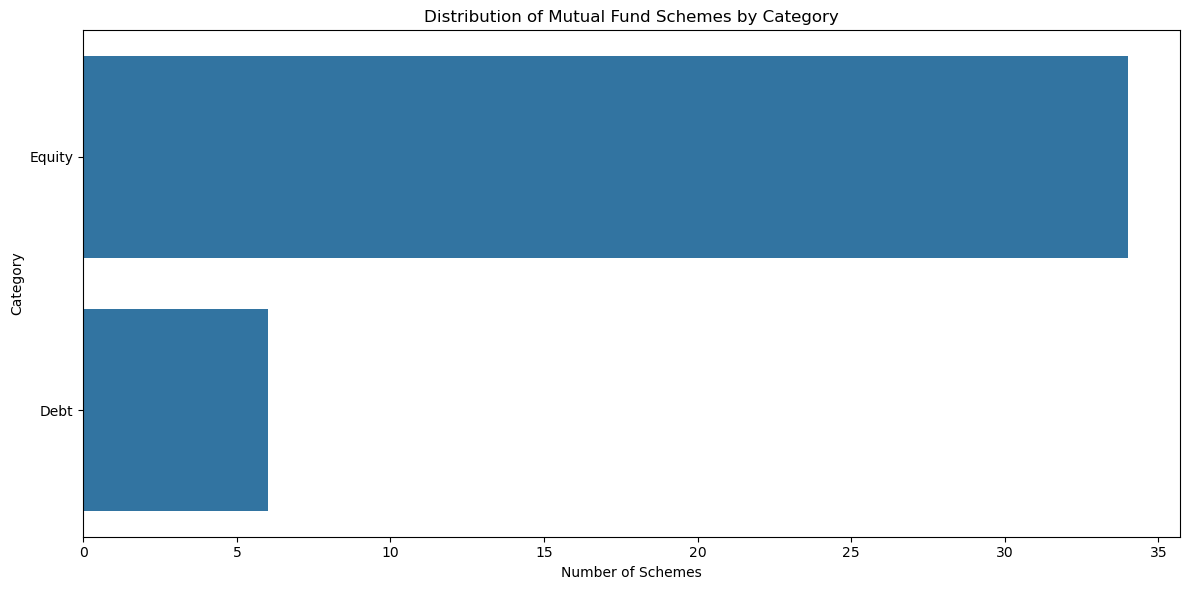

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

category_counts = (
    clean_01_fund_master['category']
    .value_counts()
    .reset_index()
)

category_counts.columns = ['Category', 'Count']

sns.barplot(
    data=category_counts,
    x='Count',
    y='Category'
)

plt.title('Distribution of Mutual Fund Schemes by Category')
plt.xlabel('Number of Schemes')
plt.ylabel('Category')

plt.tight_layout()

# plt.savefig('../reports/category_distribution.png', dpi=300)

plt.show()

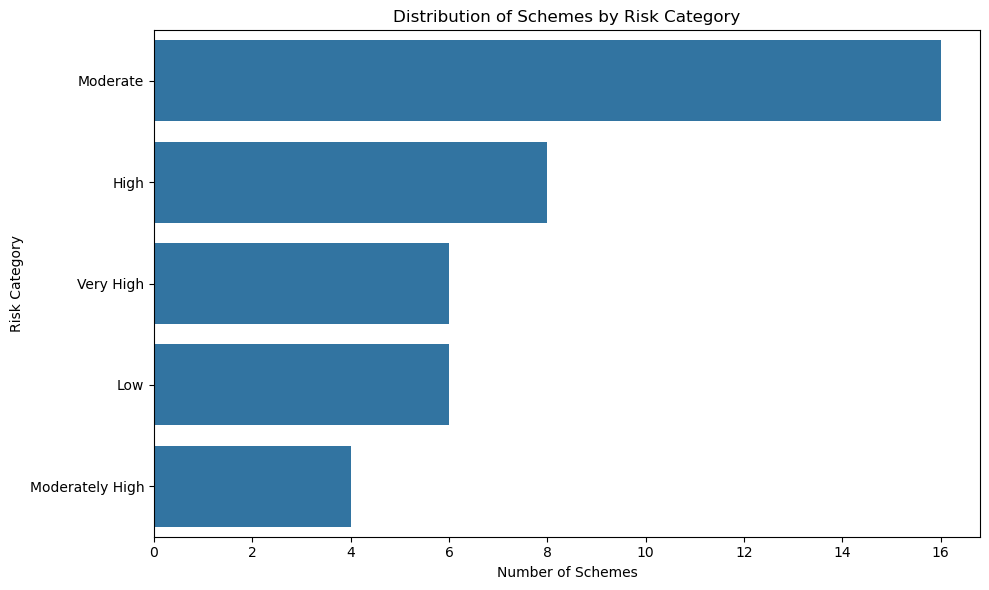

In [13]:
plt.figure(figsize=(10,6))

risk_counts = (
    clean_01_fund_master['risk_category']
    .value_counts()
    .reset_index()
)

risk_counts.columns = ['Risk Category', 'Count']

sns.barplot(
    data=risk_counts,
    x='Count',
    y='Risk Category'
)

plt.title('Distribution of Schemes by Risk Category')
plt.xlabel('Number of Schemes')
plt.ylabel('Risk Category')

plt.tight_layout()

# plt.savefig('../reports/risk_category_distribution.png', dpi=300)

plt.show()

In [17]:
plt.figure(figsize=(10,6))

sns.histplot(
    clean_02_nav_history['min_sip_amount'],
    bins=20,
    kde=True
)

plt.title('Distribution of Minimum SIP Amounts')
plt.xlabel('Minimum SIP Amount (₹)')
plt.ylabel('Number of Schemes')

plt.tight_layout()

# plt.savefig('../reports/min_sip_distribution.png', dpi=300)

plt.show()

KeyError: 'min_sip_amount'

<Figure size 1000x600 with 0 Axes>

In [15]:
clean_02_nav_history

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692
...,...,...,...
45995,149324,2026-05-25,292.4810
45996,149324,2026-05-26,291.2707
45997,149324,2026-05-27,288.8007
45998,149324,2026-05-28,280.6873


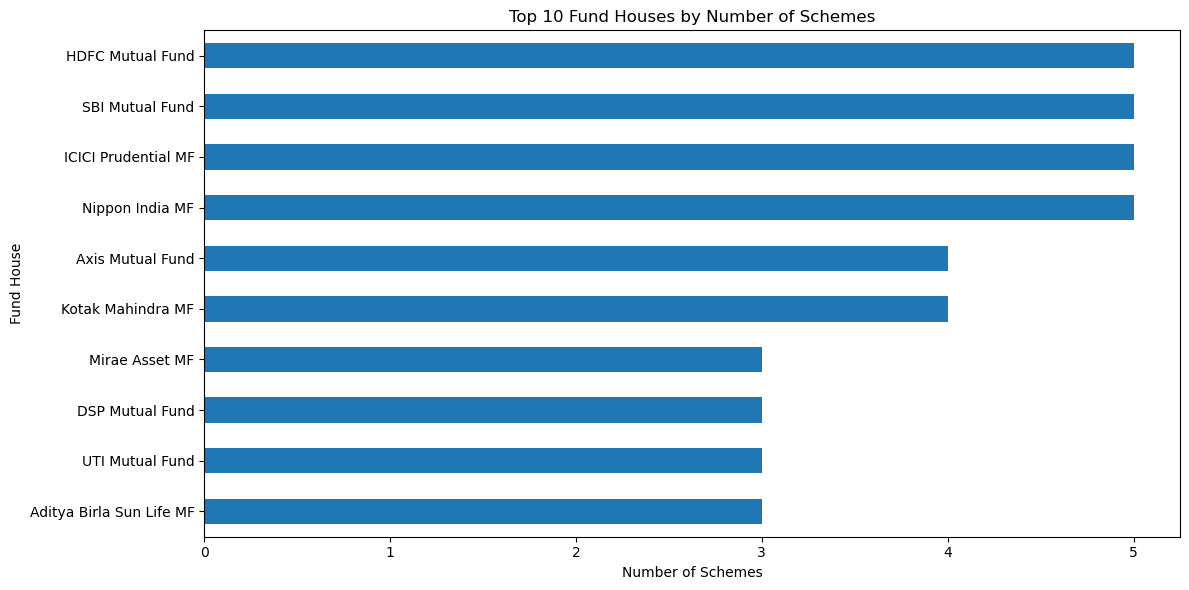

In [20]:
import matplotlib.pyplot as plt

top_funds = (
    clean_01_fund_master['fund_house']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))
top_funds.sort_values().plot(kind='barh')
plt.title('Top 10 Fund Houses by Number of Schemes')
plt.xlabel('Number of Schemes')
plt.ylabel('Fund House')
plt.tight_layout()
plt.show()

# Identify the most diversified AMCs.
# Large scheme counts often indicate wider product offerings and stronger market presence.

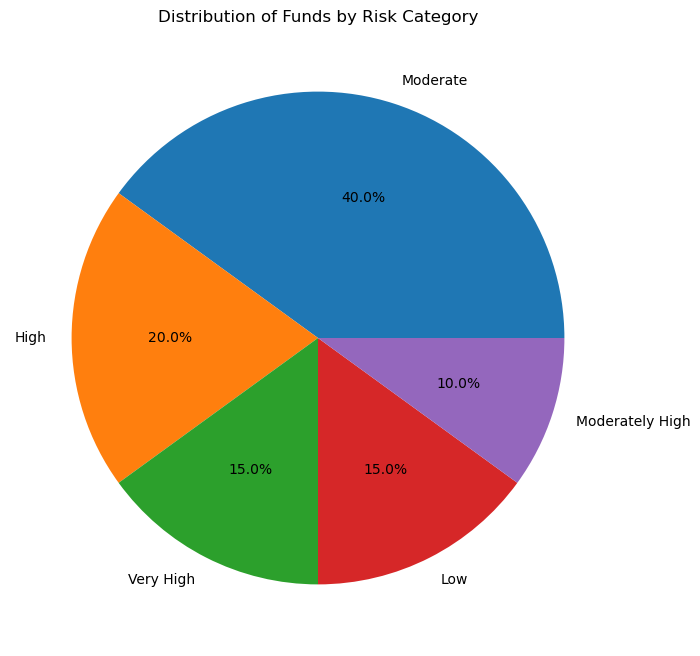

In [22]:
clean_01_fund_master['risk_category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8,8)
)

plt.title('Distribution of Funds by Risk Category')
plt.ylabel('')
plt.show()

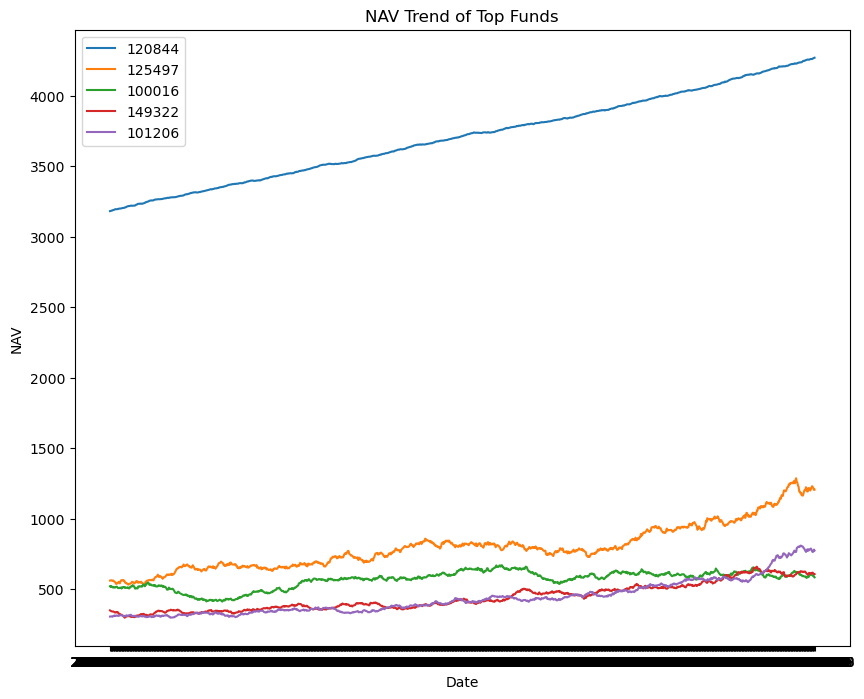

In [29]:
top_codes = (
    clean_02_nav_history.groupby('amfi_code')['nav']
    .mean()
    .nlargest(5)
    .index
)

plt.figure(figsize=(10,8))

for code in top_codes:
    temp = clean_02_nav_history[clean_02_nav_history['amfi_code']==code]
    plt.plot(temp['date'], temp['nav'], label=code)

plt.title('NAV Trend of Top Funds')
plt.xlabel('Date')
plt.ylabel('NAV')
plt.legend()
plt.show()

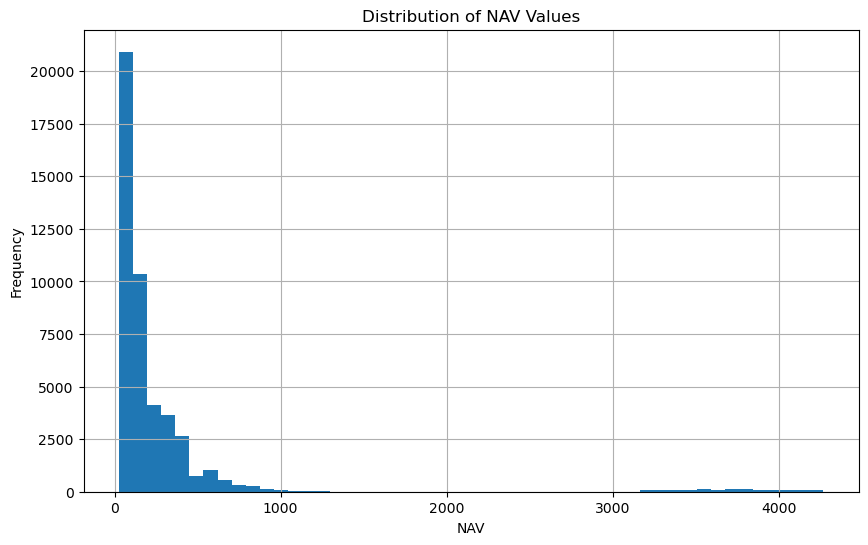

In [28]:
plt.figure(figsize=(10,6))
clean_02_nav_history['nav'].hist(bins=50)

plt.title('Distribution of NAV Values')
plt.xlabel('NAV')
plt.ylabel('Frequency')
plt.show()

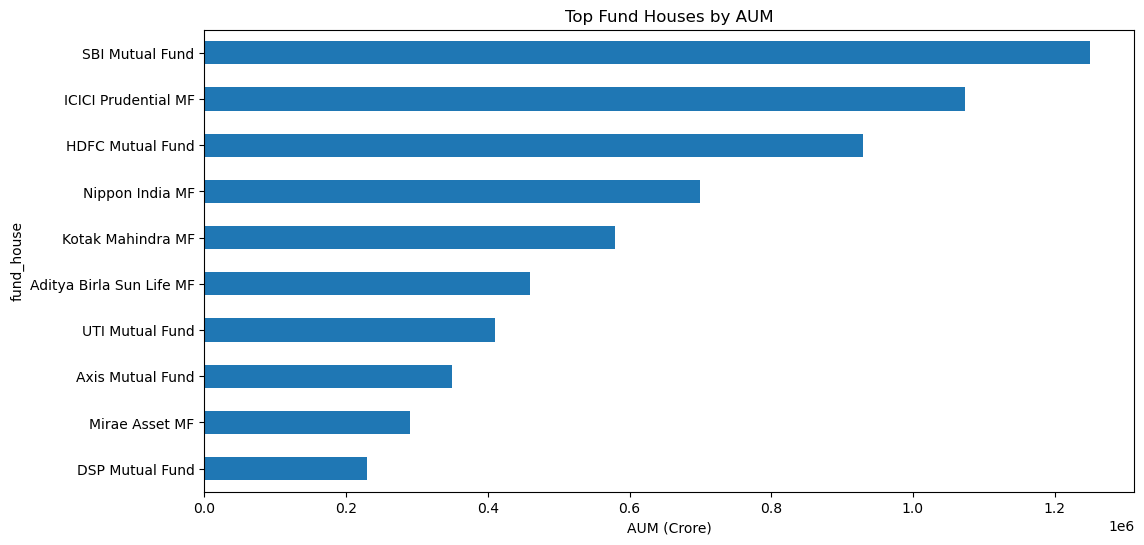

In [31]:
aum_top = (
    clean_03_aum_by_fund_house
    .groupby('fund_house')['aum_crore']
    .max()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
aum_top.sort_values().plot(kind='barh')

plt.title('Top Fund Houses by AUM')
plt.xlabel('AUM (Crore)')
plt.show()

# Shows market leaders and investor trust concentration.

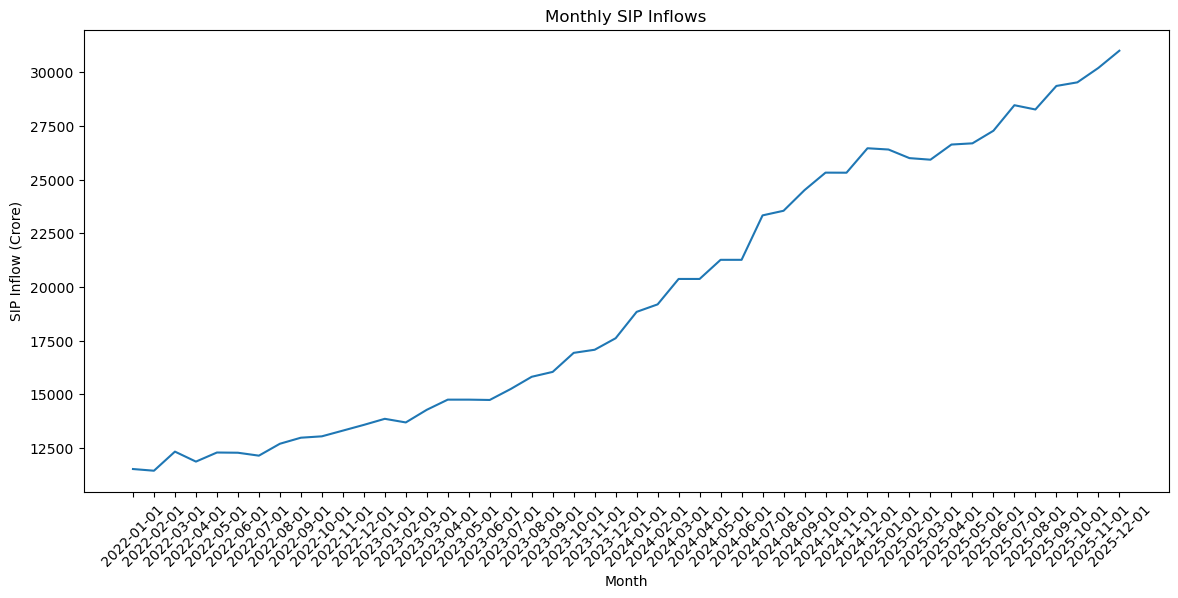

In [35]:
plt.figure(figsize=(14,6))

plt.plot(
    clean_04_monthly_sip_inflows['month'],
    clean_04_monthly_sip_inflows['sip_inflow_crore']
)

plt.title('Monthly SIP Inflows')
plt.xlabel('Month')
plt.ylabel('SIP Inflow (Crore)')
plt.xticks(rotation=45)

plt.show()
# Measures retail investor confidence and market participation.

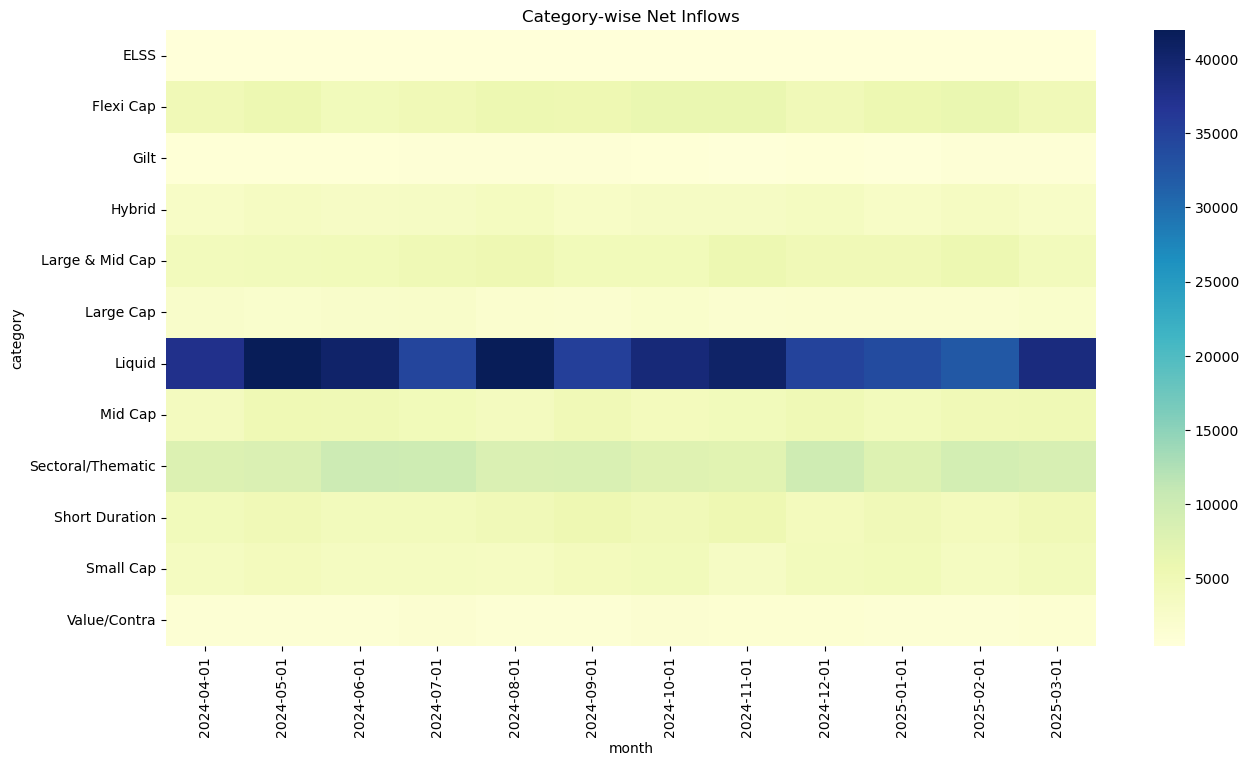

In [39]:
import seaborn as sns

pivot = clean_05_category_inflows.pivot_table(
    index='category',
    columns='month',
    values='net_inflow_crore',
    aggfunc='sum'
)

plt.figure(figsize=(15,8))

sns.heatmap(
    pivot,
    cmap='YlGnBu'
)

plt.title('Category-wise Net Inflows')
plt.show()

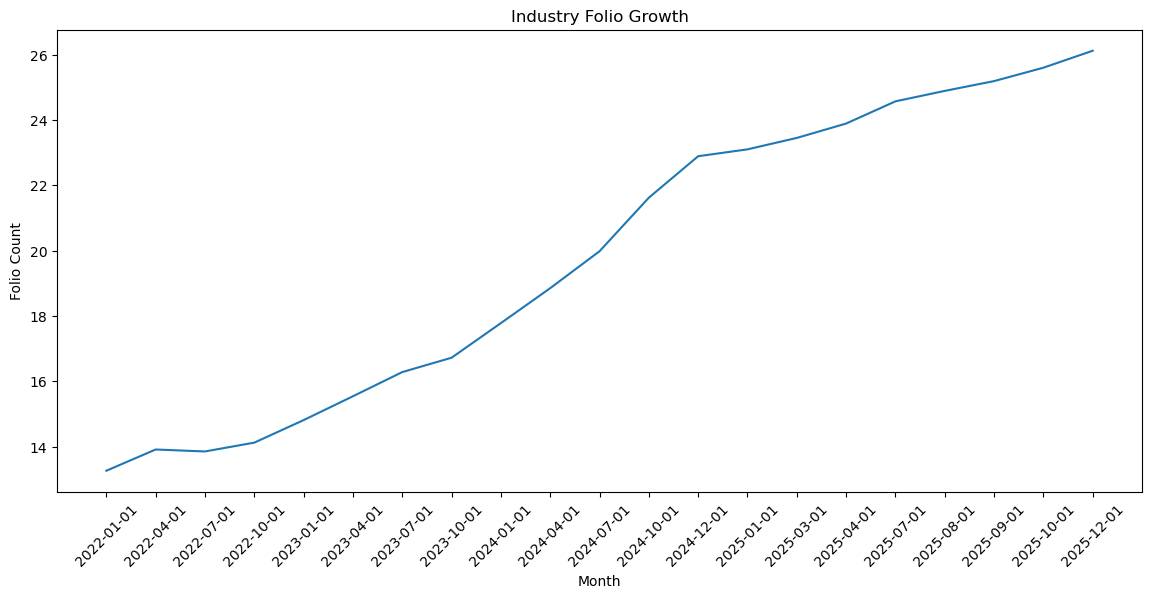

In [43]:
plt.figure(figsize=(14,6))

plt.plot(
    clean_06_industry_folio_count['month'],
    clean_06_industry_folio_count['total_folios_crore']
)

plt.title('Industry Folio Growth')
plt.xlabel('Month')
plt.ylabel('Folio Count')
plt.xticks(rotation=45)

plt.show()
# Tracks growth of mutual fund participation.  

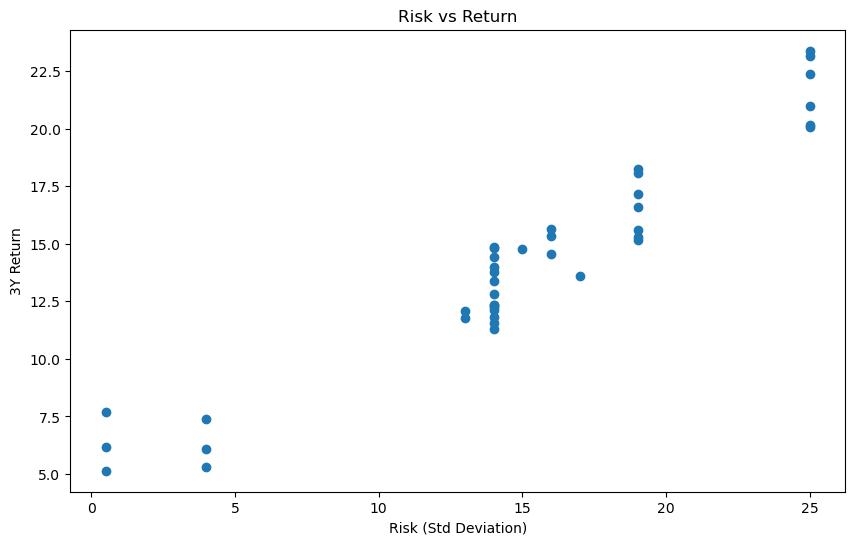

In [45]:
plt.figure(figsize=(10,6))

plt.scatter(
    clean_07_scheme_performance['std_dev_ann_pct'],
    clean_07_scheme_performance['return_3yr_pct']
)

plt.xlabel('Risk (Std Deviation)')
plt.ylabel('3Y Return')
plt.title('Risk vs Return')
plt.show() 
# Identifies funds offering superior returns for similar risk levels.

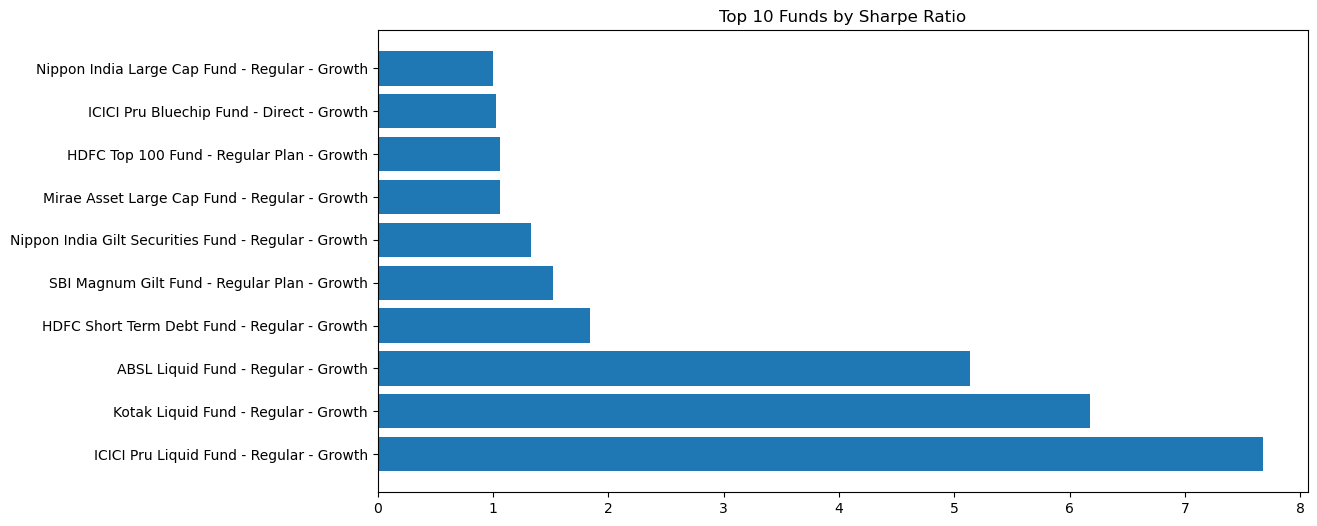

In [46]:
top_sharpe = (
    clean_07_scheme_performance
    .sort_values(
        'sharpe_ratio',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

plt.barh(
    top_sharpe['scheme_name'],
    top_sharpe['sharpe_ratio']
)

plt.title('Top 10 Funds by Sharpe Ratio')

plt.show()
# Highlights funds delivering the best risk-adjusted returns.

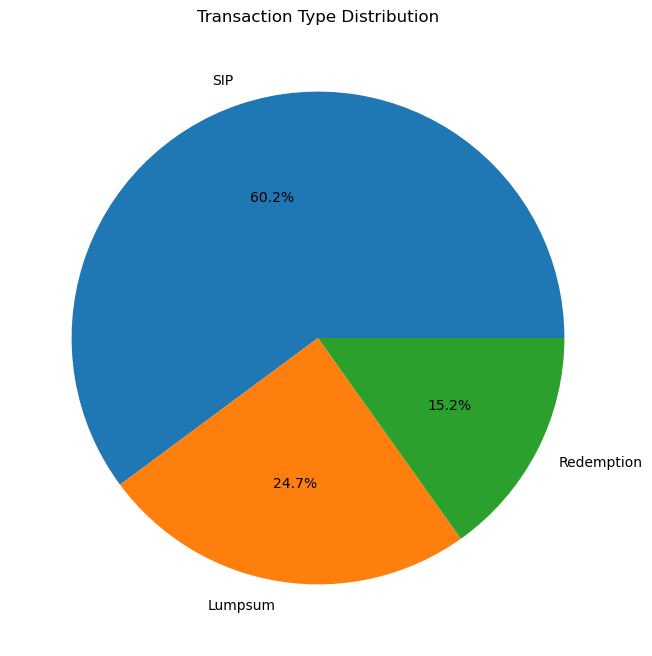

In [51]:
clean_08_investor_transactions[
    'transaction_type'
].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8,8)
)

plt.title('Transaction Type Distribution')
plt.ylabel('')
plt.show()
# Shows investor preference between SIP, Lumpsum and Redemption.

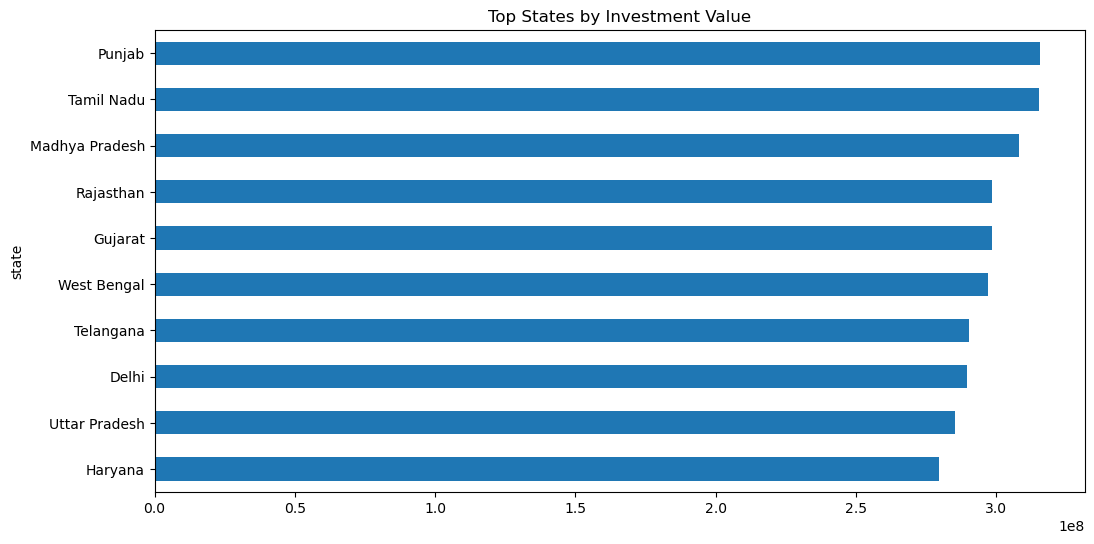

In [53]:
state_amt = (
    clean_08_investor_transactions
    .groupby('state')['amount_inr']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

state_amt.sort_values().plot(
    kind='barh'
)

plt.title('Top States by Investment Value')

plt.show()
# Identifies geographical concentration of assets.

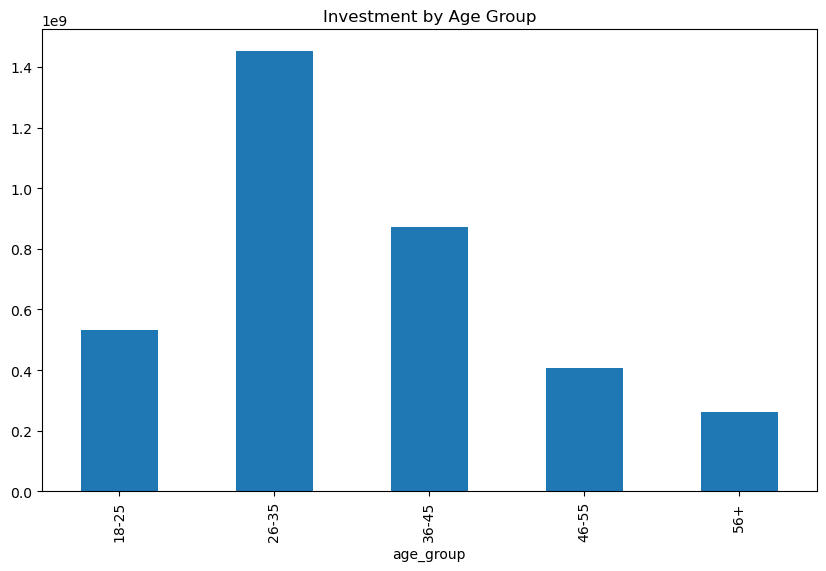

In [54]:
age_amt = (
    clean_08_investor_transactions
    .groupby('age_group')['amount_inr']
    .sum()
)

age_amt.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Investment by Age Group')

plt.show()
# Shows which demographic contributes most to mutual fund investments.

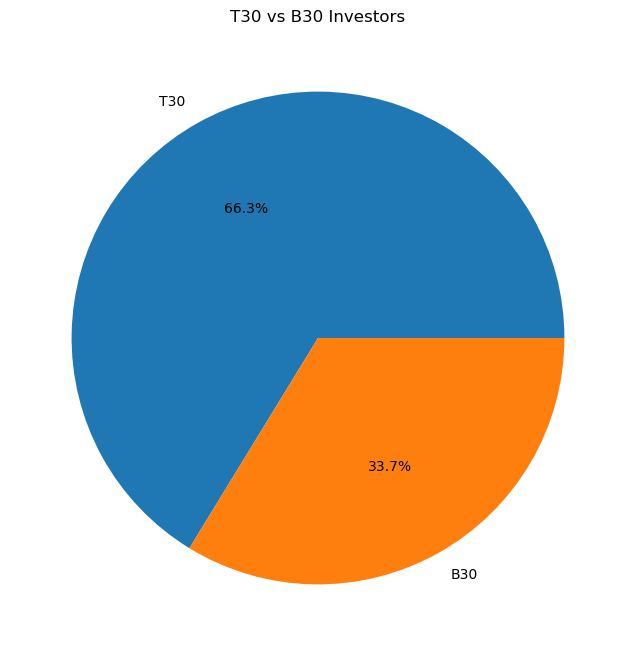

In [55]:
clean_08_investor_transactions[
    'city_tier'
].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8,8)
)

plt.title('T30 vs B30 Investors')

plt.ylabel('')
plt.show()
# Measures penetration beyond major metropolitan cities.

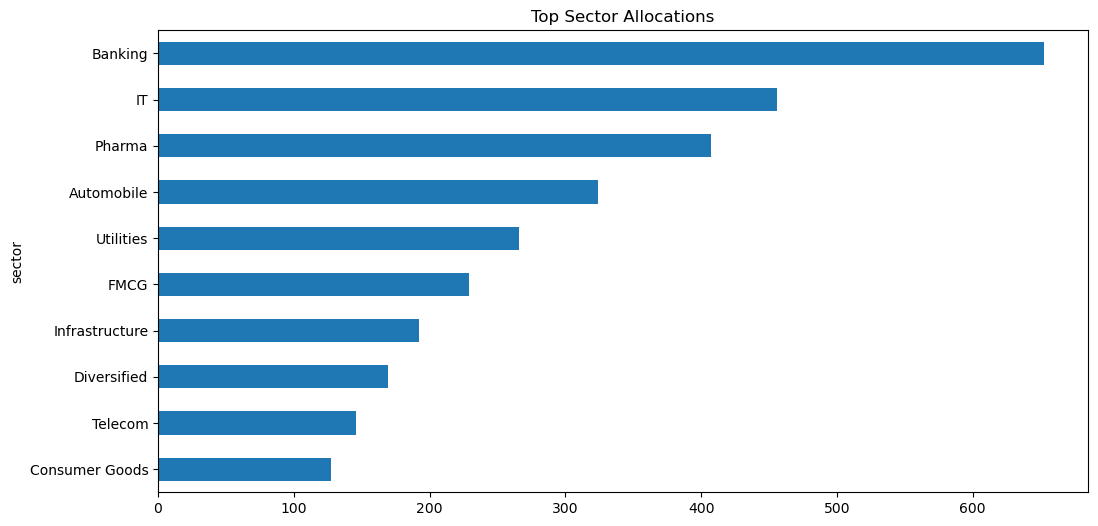

In [59]:
sector = (
    clean_09_portfolio_holdings
    .groupby('sector')['weight_pct']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sector.sort_values().plot(
    kind='barh'
)

plt.title('Top Sector Allocations')

plt.show()
# Reveals sector concentration and diversification patterns.

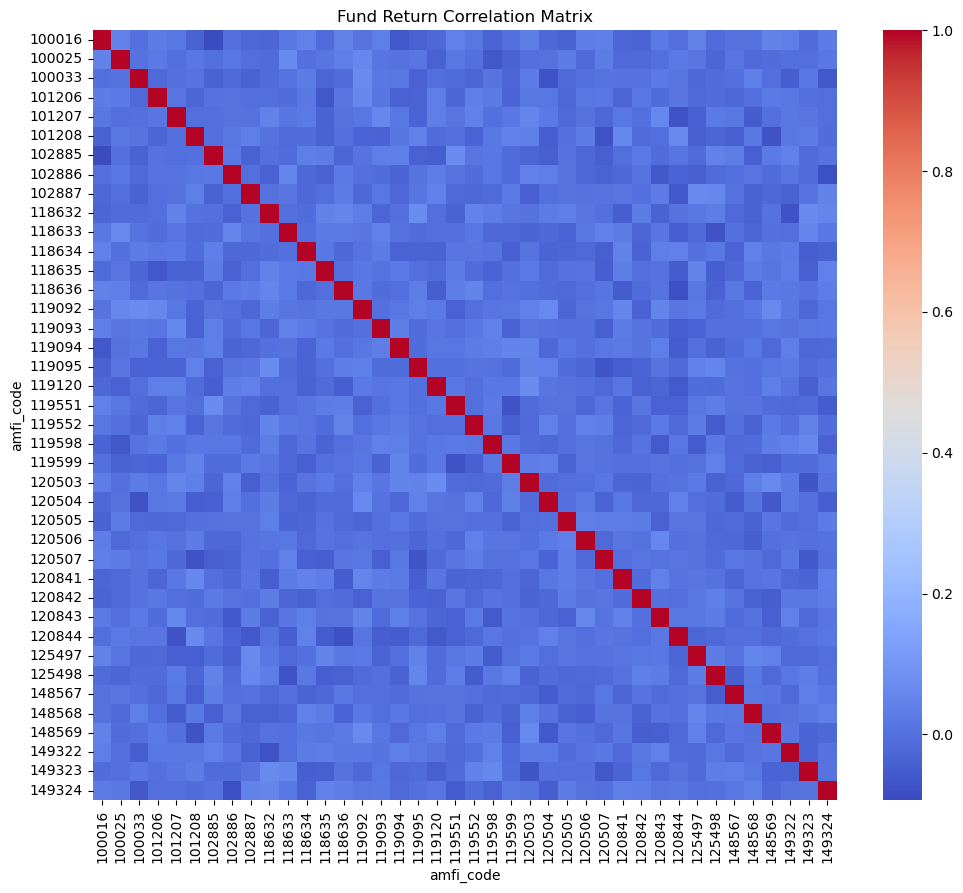

In [61]:
returns = (
    clean_02_nav_history
    .pivot(
        index='date',
        columns='amfi_code',
        values='nav'
    )
    .pct_change()
)

corr = returns.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap='coolwarm'
)

plt.title('Fund Return Correlation Matrix')

plt.show()